
User Balances:
Alice : 200.0
Bob : -100.0
Carol : 100.0
Dave : -200.0

Settlement:
Dave pays Carol Rs.100.00
Dave pays Alice Rs.100.00
Bob pays Alice Rs.100.00

Expense DataFrame:
   Payer  Amount          Participants
0  Alice     400  Alice,Bob,Carol,Dave
1    Bob     200             Alice,Bob
2  Carol     300        Bob,Carol,Dave


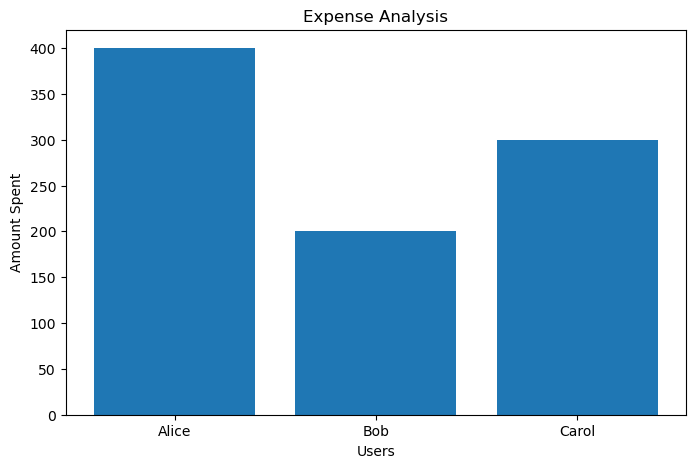

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
class ExpenseSharing:
    def __init__(self, users):
        self.users = users
        self.balances = {user: 0 for user in users}
        self.transactions = []

    def add_expense(self, payer, amount, participants):

        split_amount = amount / len(participants)

        for participant in participants:
            self.balances[participant] -= split_amount

        self.balances[payer] += amount

        self.transactions.append({
            "payer": payer,
            "amount": amount,
            "participants": participants
        })

    def calculate_settlement(self):

        creditors = []
        debtors = []

        for user, balance in self.balances.items():

            if balance > 0:
                creditors.append([user, balance])

            elif balance < 0:
                debtors.append([user, -balance])

        settlements = []

        while debtors and creditors:

            debtor, debt_amount = debtors.pop()
            creditor, credit_amount = creditors.pop()

            payment = min(debt_amount, credit_amount)

            settlements.append(
                f"{debtor} pays {creditor} Rs.{payment:.2f}"
            )

            debt_amount -= payment
            credit_amount -= payment

            if debt_amount > 0:
                debtors.append([debtor, debt_amount])

            if credit_amount > 0:
                creditors.append([creditor, credit_amount])

        return settlements
        
    def show_balances(self):
        print("\nUser Balances:")
        for user, balance in self.balances.items():
            print(user, ":", round(balance, 2))
            
    def expense_dataframe(self):
        data = []
        for transaction in self.transactions:
            data.append({
                "Payer": transaction["payer"],
                "Amount": transaction["amount"],
                "Participants": ",".join(transaction["participants"])
            })

        return pd.DataFrame(data)

    def visualize_expenses(self):
        total_spending = {}
        for transaction in self.transactions:
            payer = transaction["payer"]
            if payer not in total_spending:
                total_spending[payer] = 0
            total_spending[payer] += transaction["amount"]
        users = list(total_spending.keys())
        amounts = list(total_spending.values())
        plt.figure(figsize=(8, 5))
        plt.bar(users, amounts)
        plt.xlabel("Users")
        plt.ylabel("Amount Spent")
        plt.title("Expense Analysis")
        plt.show()

if __name__ == "__main__":
    users = ["Alice", "Bob", "Carol", "Dave"]
    expense_system = ExpenseSharing(users)
    expense_system.add_expense("Alice",400,["Alice", "Bob", "Carol", "Dave"])
    expense_system.add_expense("Bob",200,["Alice", "Bob"])
    expense_system.add_expense("Carol",300,["Bob", "Carol", "Dave"])
    expense_system.show_balances()
    print("\nSettlement:")
    result = expense_system.calculate_settlement()
    for item in result:
        print(item)
    df = expense_system.expense_dataframe()
    print("\nExpense DataFrame:")
    print(df)
    expense_system.visualize_expenses()